In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

df = sns.load_dataset('tips')
print("Dataset Head:")
print(df.tail())

print("\nSummary Statistics:")
print(df.describe())

Dataset Head:
     total_bill   tip     sex smoker   day    time  size
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

Summary Statistics:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


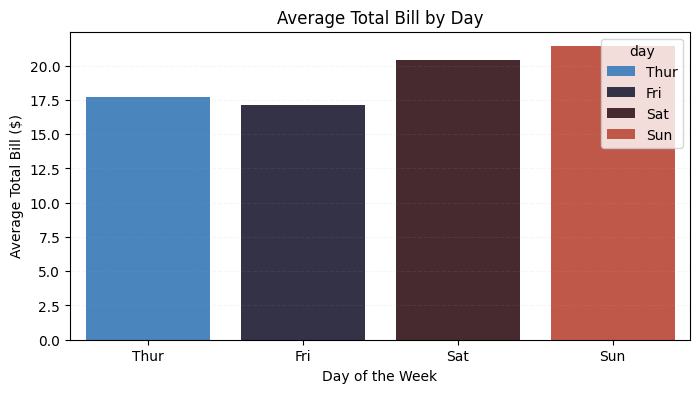

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Bar Chart without error bars
plt.figure(figsize=(8, 4))
sns.barplot(x='day', y='total_bill', data=df, estimator=np.mean, palette='icefire', hue='day', legend=True, errorbar=None)

plt.title('Average Total Bill by Day')
plt.xlabel('Day of the Week')
plt.ylabel('Average Total Bill ($)')
plt.grid(axis='y', linestyle='--', alpha=0.1)
plt.show()

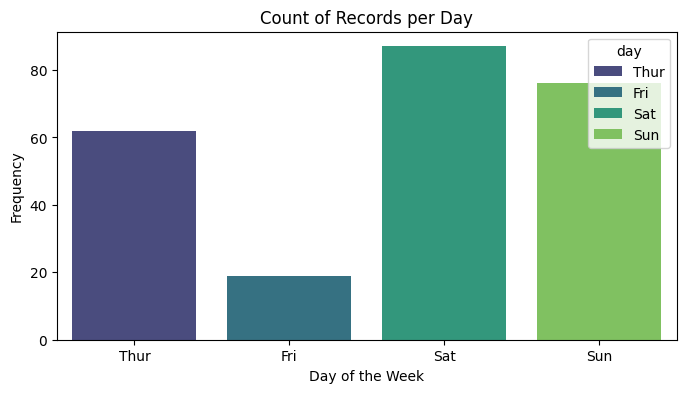

The most common category is: Sat


In [ ]:
# Task 2: Count Plot:
plt.figure(figsize=(8, 4))
sns.countplot(x='day', data=df, palette='viridis', hue='day', legend=True)
plt.title('Count of Records per Day')
plt.xlabel('Day of the Week')
plt.ylabel('Frequency')
plt.show()

most_common = df['day'].value_counts().idxmax()
print(f"The most common category is: {most_common}")

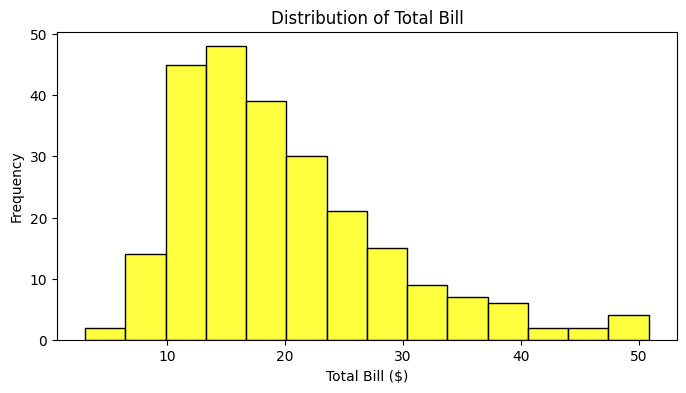

The distribution is skewed right, as the tail extends towards the higher values.


In [ ]:
#Task 3: Histogram
plt.figure(figsize=(8, 4))
sns.histplot(df['total_bill'], kde=False, color='yellow')
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')
plt.show()

print("The distribution is skewed right, as the tail extends towards the higher values.")

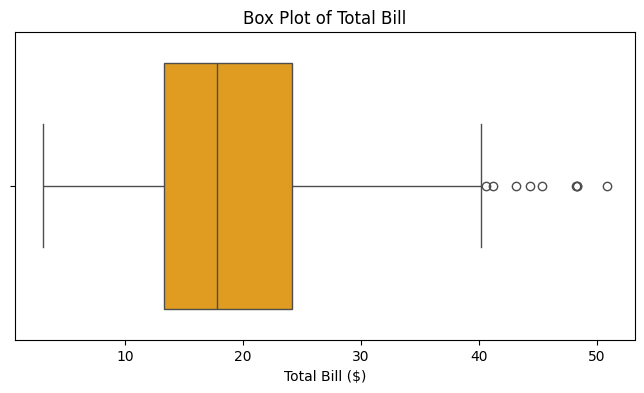

In [ ]:
 #Task 4: Box Plot

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['total_bill'], color='orange')
plt.title('Box Plot of Total Bill')
plt.xlabel('Total Bill ($)')
plt.show()

In [ ]:

print("By looking at the plot, there are 9 outliers beyond the right whisker.")

By looking at the plot, there are 9 outliers beyond the right whisker.


### Task 5: Outlier Detection - The IQR Mechanism
Calculating the Interquartile Range (IQR) to identify statistical outliers in the `total_bill` column.

In [ ]:

Q1 = df['total_bill'].quantile(0.25)
Q3 = df['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['total_bill'] < lower_bound) | (df['total_bill'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:.2f}")
print(f"Q3 (75th percentile): {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")
print(f"\nNumber of outliers detected analytically: {len(outliers)}")


display(outliers)

Q1 (25th percentile): 13.35
Q3 (75th percentile): 24.13
IQR: 10.78
Lower Bound: -2.82
Upper Bound: 40.30

Number of outliers detected analytically: 9


,total_bill,tip,sex,smoker,day,time,size
59,48.27,6.73,Male,No,Sat,Dinner,4
102,44.30,2.50,Female,Yes,Sat,Dinner,3
142,41.19,5.00,Male,No,Thur,Lunch,5
156,48.17,5.00,Male,No,Sun,Dinner,6
170,50.81,10.00,Male,Yes,Sat,Dinner,3
182,45.35,3.50,Male,Yes,Sun,Dinner,3
184,40.55,3.00,Male,Yes,Sun,Dinner,2
197,43.11,5.00,Female,Yes,Thur,Lunch,4
212,48.33,9.00,Male,No,Sat,Dinner,4


In [ ]:
print("Outlier are 9 that is same as counted from Box-Plot")

Outlier are 9 that is same as counted from Box-Plot


In [ ]:
#Task 6:
from scipy import stats

df['zscore'] = stats.zscore(df['total_bill'])

outliers_z = df[df['zscore'].abs() > 3]

print(f"Number of outliers detected using Z-score (>3): {len(outliers_z)}")
display(outliers_z)

print(f"\nIQR flagged 9 outliers, while Z-score flagged {len(outliers_z)}.")

Number of outliers detected using Z-score (>3): 4


,total_bill,tip,sex,smoker,day,time,size,zscore
59,48.27,6.73,Male,No,Sat,Dinner,4,3.206166
156,48.17,5.00,Male,No,Sun,Dinner,6,3.194910
170,50.81,10.00,Male,Yes,Sat,Dinner,3,3.492068
212,48.33,9.00,Male,No,Sat,Dinner,4,3.212919



IQR flagged 9 outliers, while Z-score flagged 4.


**Why do they differ?**

The IQR method is robust and does not assume a normal distribution. In Task 3, we observed that `total_bill` is **right-skewed**. The Z-score method assumes the data is roughly symmetric (bell-shaped). In skewed data, the mean and standard deviation are pulled upward by extreme values, which stretches the standard deviation and makes the Z-score thresholds wider, often hiding outliers that the IQR method would otherwise catch.

### Task 7: Scatter Plot - Relationship Between Two Variables
We will visualize the relationship between the `total_bill` and the `tip` amount, using `day` as a hue to distinguish different categories.

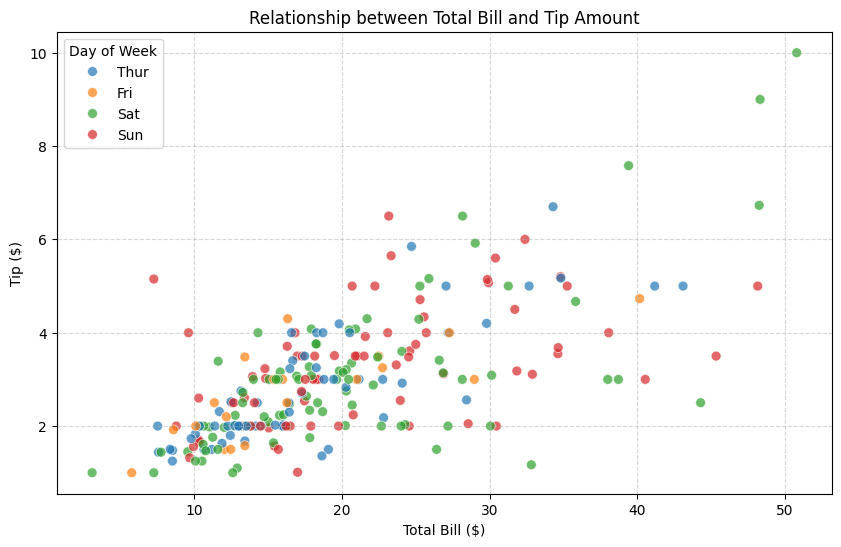

The correlation coefficient is: 0.68


In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_bill', y='tip', data=df, hue='day', s=50, alpha=0.7)

plt.title('Relationship between Total Bill and Tip Amount')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.legend(title='Day of Week')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
correlation = df['total_bill'].corr(df['tip'])
print(f"The correlation coefficient is: {correlation:.2f}")

**Relationship Observation:**
Based on the plot and the correlation coefficient, there appears to be a **strong positive relationship**. As the `total_bill` increases, the `tip` generally increases as well. The relationship looks linear, though there is more variance (spread) at higher bill amounts.

### Task 8: Line and Area Chart - Trends Across an Ordered Variable
We will examine the average `total_bill` across the days of the week (Thur, Fri, Sat, Sun).

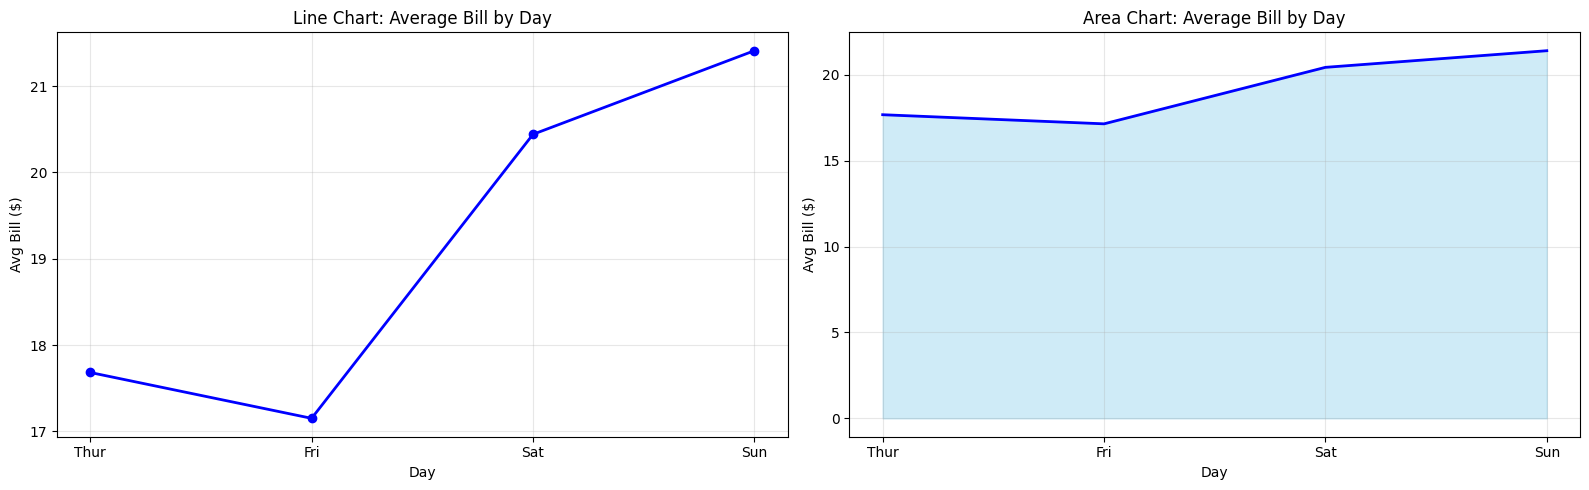

In [ ]:
# Calculate daily averages in the correct order
day_order = ['Thur', 'Fri', 'Sat', 'Sun']
daily_avg = df.groupby('day', observed=True)['total_bill'].mean().reindex(day_order).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Line Chart
ax1.plot(daily_avg['day'], daily_avg['total_bill'], marker='o', color='b', linewidth=2)
ax1.set_title('Line Chart: Average Bill by Day')
ax1.set_xlabel('Day')
ax1.set_ylabel('Avg Bill ($)')
ax1.grid(True, alpha=0.3)

# 2. Area Chart
ax2.plot(daily_avg['day'], daily_avg['total_bill'], color='b', linewidth=2)
ax2.fill_between(daily_avg['day'], daily_avg['total_bill'], color='skyblue', alpha=0.4)
ax2.set_title('Area Chart: Average Bill by Day')
ax2.set_xlabel('Day')
ax2.set_ylabel('Avg Bill ($)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 9: Graphical Integrity - Truncated Y-Axis Comparison
We will compare a standard bar chart (starting at 0) with a truncated one to see how visual perception can be manipulated.

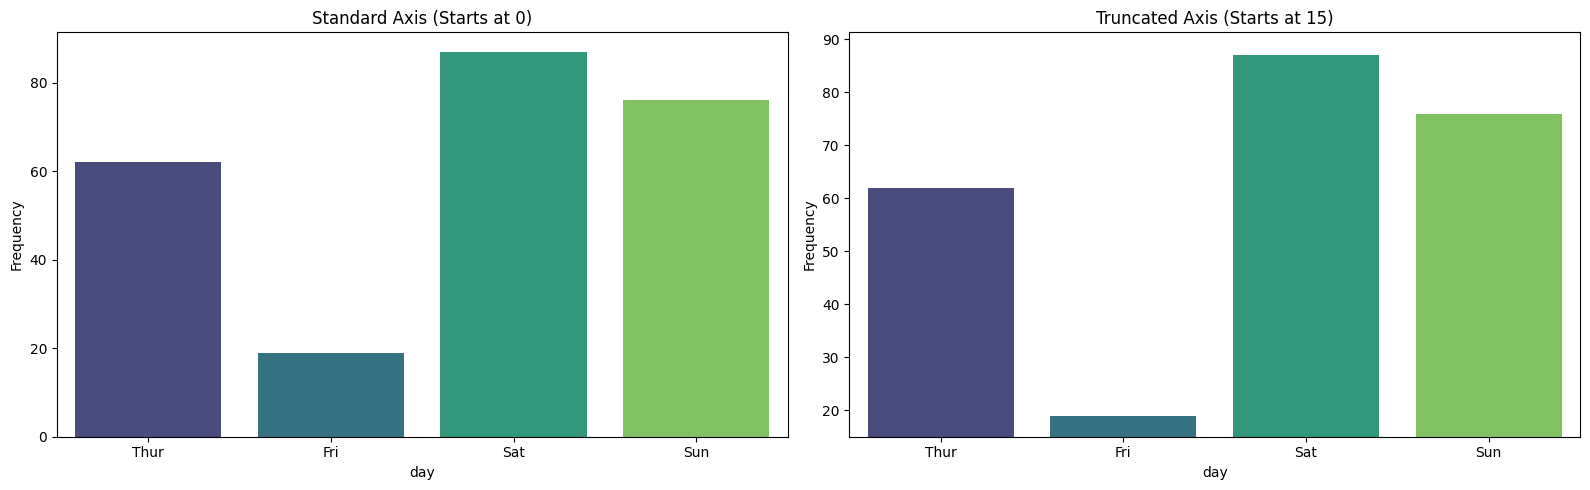

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 1. Honest Plot (Starts at 0)
sns.countplot(x='day', data=df, palette='viridis', hue='day', legend=False, ax=ax1)
ax1.set_title('Standard Axis (Starts at 0)')
ax1.set_ylabel('Frequency')

# 2. Misleading Plot (Truncated Axis)
sns.countplot(x='day', data=df, palette='viridis', hue='day', legend=False, ax=ax2)
ax2.set_ylim(bottom=15)  # Deliberately truncating the axis
ax2.set_title('Truncated Axis (Starts at 15)')
ax2.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Analysis of Graphical Integrity:**
The truncated axis (starting at 15) significantly changes the visual impression of the data. In the second plot, the bar for Friday looks tiny compared to Saturday, creating the illusion of a massive gap, whereas the first plot shows that the differences are much more moderate. This demonstrates why starting the y-axis at zero is crucial for honest data representation.

**Visual Comparison:**
*   The **Line Chart** emphasizes the specific changes and the magnitude of the slope between days.
*   The **Area Chart** gives more visual 'weight' to the values. It emphasizes the total volume or cumulative feeling of the spending, making the differences between Saturday and other days feel more substantial.